In [3]:
print(sys.executable)

g:\Mi unidad\Tesis v1\mt\Scripts\python.exe


## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np

project_path = 'G:\\Mi unidad\\Tesis v1\\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)
sys.path.append(project_path)


#Elegimos la ruta donde trabajaremos con colab
BASE_FOLDER = os.getcwd() #Ruta actual del proyecto

#Rutas donde tenemos demás recursos
scripts_path = os.path.join(BASE_FOLDER, 'scripts')
note_path = os.path.join(BASE_FOLDER, 'notebooks')
resources_path = os.path.join(BASE_FOLDER, 'Recursos')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")
if os.path.exists(note_path): #
    if note_path not in sys.path:
        sys.path.append(note_path)
        print(f"✅ Path agregado: {note_path}")
else: print(f"No encontrse encontró la carpeta en {note_path}")
if os.path.exists(resources_path):#Donde están nuestros datos
    if resources_path not in sys.path:
        sys.path.append(resources_path)
        print(f"✅ Path agregado: {resources_path}")
else: print(f"No encontrse encontró la carpeta en {resources_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1\Movement_clasify
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\notebooks
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\Recursos


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [3]:


"""            
            0: FULL           
            1: SOLO MOTOR (5 clases)
            2: SOLO IMAGINADO 5 CLASES
            3: 9 CLASES SIN FUSIÓN
            4: REST-IZQ-DER fusionado
            5: REST-MANOS-PIES fusionado
            6: REST-IZQ-DER SOLO MOTOR
            7: REST-MANOS-PIES SOLO MOTOR
            8: TODAS CLASES BINARIO (REST vs MOVIMIENTO)
            9: REST vs MOVIMIENTO SOLO MOTOR
            10: MANOS VS PIES, fusionado
            11: MANOS VS PIES, solo motor
            12: DERECHA vs IZQUIERDA, fusionado 
            13: DERECHA vs IZQUIERDA, solo motor
            14: IZQ-DER-MANO-PIES FUSIONADAS
            15: IZQ-DER-MANO-PIES SOLO MOTOR
"""

#Probamos nuestro nuevo objeto
pick = 4
obj = dl.Selection(pick=pick, Debug=False)



### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [4]:
path_dataset = "Recursos/3_ch/101_subs/eeg_dataset_0.00015rate.npz"
obj.load(path_dataset)
#obj.pick_ch(["C3..", "C4..", "Cz.."])
print("y antes del pipeline:", np.unique(obj.y, return_counts=True))
#obj.resume_dataset(subs=True)


✔️ Dataset cargado desde: Recursos/3_ch/101_subs/eeg_dataset_0.00015rate.npz
y antes del pipeline: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([86250, 10800, 10990, 10870, 10890, 10855, 10915, 10735, 10955]))


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [5]:
obj.pipeline(undersample_rest=True)

# Debug inmediato
print("y único:", np.unique(obj.y))
print("conteos:", np.unique(obj.y, return_counts=True))
print("X shape:", obj.X.shape)



Undersampling: clase 0 recortada de 86250 a 21905 muestras.
y único: [0 1 2]
conteos: (array([0, 1, 2], dtype=int32), array([21905, 21655, 21905]))
X shape: (65465, 3, 160)


### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [6]:
obj.resume_data()



X shape: (65465, 3, 160)
y shape: (65465,)
sub shape: (65465,)
trial shape: (65465,)
run shape: (65465,)
Número de clases: 3
Número de sujetos: 97

Clases:
   codigo nombre
0       0   rest
1       1  right
2       2   left

Conteo por clase:
0    21905
1    21655
2    21905
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [7]:
data_model, data_fine = obj.pick_fine(7)

print("Distribución de clases en data_model:", np.unique(data_model.y, return_counts=True))
print("Distribución de clases en data_fine:", np.unique(data_fine.y, return_counts=True))

Distribución de clases en data_model: (array([0, 1, 2], dtype=int32), array([21678, 21435, 21675]))
Distribución de clases en data_fine: (array([0, 1, 2], dtype=int32), array([227, 220, 230]))


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

In [8]:
modelo, history, mean, std, keras_split, info = dl.eeg_train(
    data_model, test_size=0.15, val_size=0.15, 
    mode="subject",
    epochs=60,
    debug=True
)

Modo de split: subject
Split por grupo:
  Train: 45268 muestras, grupos: [  2   3   4   6   8   9  10  16  18  20  21  23  24  25  27  28  29  31
  32  33  36  38  39  40  42  43  46  48  49  51  52  53  54  55  56  57
  59  60  64  65  66  67  68  69  70  71  73  74  78  79  80  82  84  85
  87  91  93  94  95  97  98 101 102 103 105 106 108]
  Val:   9416 muestras, grupos: [ 11  35  45  47  50  58  72  76  77  81  89  96  99 107]
  Test:  10104 muestras, grupos: [ 1  5 12 14 15 19 22 26 30 34 37 44 75 86 90]
Modo split: subject
X_train: (45268, 3, 160)
X_val: (9416, 3, 160)
X_test: (10104, 3, 160)
Antes de normalizar: (45268, 3, 160) Después de normalizar: (45268, 3, 160) Después de ajustar para Keras: (45268, 3, 160, 1)


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3819 - loss: 1.0837 - val_accuracy: 0.3811 - val_loss: 1.0893
Epoch 2/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3940 - loss: 1.0783 - val_accuracy: 0.3816 - val_loss: 1.0891
Epoch 3/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3976 - loss: 1.0748 - val_accuracy: 0.3831 - val_loss: 1.0870
Epoch 4/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4037 - loss: 1.0735 - val_accuracy: 0.3884 - val_loss: 1.0858
Epoch 5/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4022 - loss: 1.0736 - val_accuracy: 0.3821 - val_loss: 1.0866
Epoch 6/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4020 - loss: 1.0721 - val_accuracy: 0.3803 - val_loss: 1.0889
Epoch 7/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4053 - loss: 1.0712 - val_accuracy: 0.3777 - val_loss: 1.0864
Epoch 8/60
1415/1415 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4086 - loss: 1.0697 - 

##### Examinar modelo obtenido

316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: right
  2: left

Matriz de confusión (conteos):
[[1164  527 1683]
 [ 510  866 1994]
 [ 502  594 2264]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.53      0.34      0.42      3374
       right       0.44      0.26      0.32      3370
        left       0.38      0.67      0.49      3360

    accuracy                           0.42     10104
   macro avg       0.45      0.43      0.41     10104
weighted avg       0.45      0.42      0.41     10104



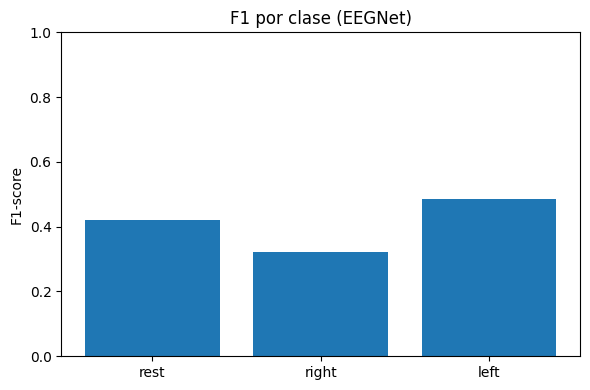

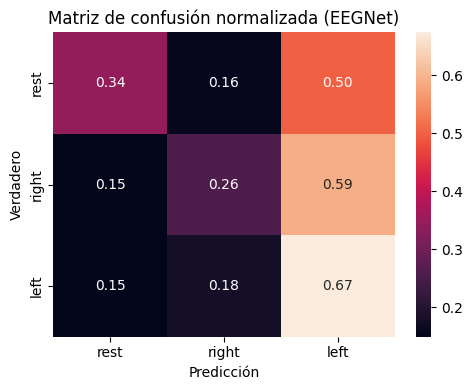

{'y_pred': array([2, 2, 1, ..., 2, 2, 2], shape=(10104,)),
 'cm': array([[1164,  527, 1683],
        [ 510,  866, 1994],
        [ 502,  594, 2264]]),
 'cm_norm': array([[0.34499111, 0.15619443, 0.49881446],
        [0.15133531, 0.25697329, 0.59169139],
        [0.14940476, 0.17678571, 0.67380952]]),
 'precision': array([0.53492647, 0.43583291, 0.38108063]),
 'recall': array([0.34499111, 0.25697329, 0.67380952]),
 'f1': array([0.41945946, 0.32331529, 0.48682937])}

In [9]:
dl.evaluate(modelo, keras_split, obj.label_map)

In [18]:
#Guardamos el modelo y sus parámetros de normalización
clases = np.unique(obj.pick)
path = f"Recursos/models/general/v2/{pick}_mode_trained_models_v1"

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(
    model=modelo,
    mean=mean,
    std=std,
    label_map=obj.label_map,
    path=path,
    name="EEGNet_LR3_v1"
)



Modelo guardado: Recursos/models/general/v2/4_mode_trained_models_v1\EEGNet_LR3_v1.keras
Parámetros guardados: Recursos/models/general/v2/4_mode_trained_models_v1\EEGNet_LR3_v1.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('right'), 2: np.str_('left')}


In [10]:
#Cargar modelo en caso de que ya tenegamos uno guardado
#modelo, mean, std = dl.load_model(model_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/Gmodel_166170_97.keras", 
#                                  params_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/EEGnet_general_166170_97.npz")


In [14]:
modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft = dl.eeg_fine(modelo, data_fine, mean = mean, std = std, test_size=0.15, val_size=0.15,
                                                        debug=False, epochs=150, lr=2e-4, batch_size=16, unfreeze_last_n=None, normalize=False)


[Fine-tune] Test loss=0.6677, acc=0.7264


Distribución de train (array([0, 1, 2], dtype=int32), array([157, 155, 150]))
Distribución de validation (array([0, 1, 2], dtype=int32), array([34, 25, 50]))
Distribución de test (array([0, 1, 2], dtype=int32), array([36, 40, 30]))
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: right
  2: left

Matriz de confusión (conteos):
[[23  6  7]
 [ 2 29  9]
 [ 0  5 25]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.92      0.64      0.75        36
       right       0.72      0.72      0.72        40
        left       0.61      0.83      0.70        30

    accuracy                           0.73       106
   macro avg       0.75      0.73      0.73       106
weighted avg       0.76      0.73      0.73       106



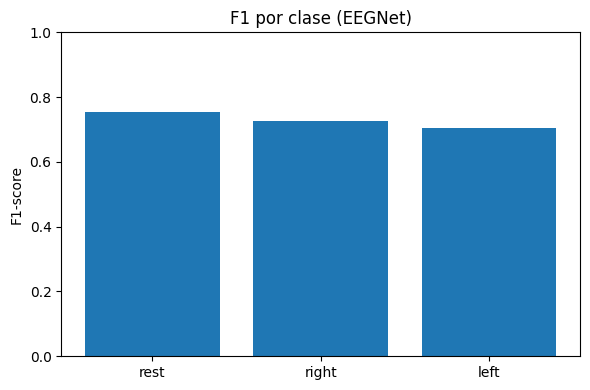

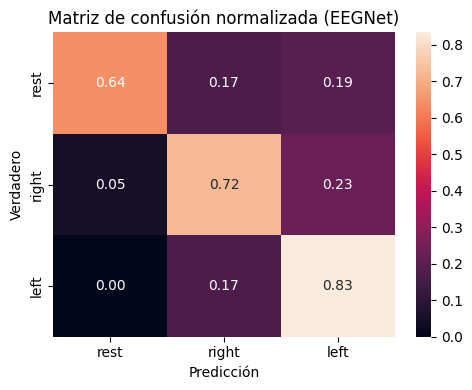

{'y_pred': array([2, 0, 1, 1, 1, 0, 2, 0, 1, 2, 1, 2, 2, 1, 0, 1, 2, 1, 2, 0, 2, 0,
        1, 2, 2, 0, 2, 1, 1, 2, 2, 2, 1, 2, 0, 2, 0, 1, 2, 2, 1, 2, 0, 0,
        1, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 2, 0, 1, 0, 2, 1, 1, 2, 2, 1, 2,
        2, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 1, 0, 1, 1, 1, 1,
        1, 0, 2, 2, 1, 1, 1, 1, 0, 1, 1, 2, 0, 0, 2, 2, 0, 2]),
 'cm': array([[23,  6,  7],
        [ 2, 29,  9],
        [ 0,  5, 25]]),
 'cm_norm': array([[0.63888889, 0.16666667, 0.19444444],
        [0.05      , 0.725     , 0.225     ],
        [0.        , 0.16666667, 0.83333333]]),
 'precision': array([0.92     , 0.725    , 0.6097561]),
 'recall': array([0.63888889, 0.725     , 0.83333333]),
 'f1': array([0.75409836, 0.725     , 0.70422535])}

In [15]:
print("Distribución de train", np.unique(keras_split_ft.y.train, return_counts=True))
print("Distribución de validation", np.unique(keras_split_ft.y.val, return_counts=True))
print("Distribución de test", np.unique(keras_split_ft.y.test, return_counts=True))
dl.evaluate(modelo_ft, keras_split_ft, obj.label_map)

In [17]:

path_f = f"Recursos/models/fined/v2/{pick}_mode_finned_model_v1"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(
    model=modelo_ft,
    mean=mean_ft,
    std=std_ft,
    label_map=obj.label_map,
    path=path_f,
    name="EEGNet_LR3_subject07_ft_v1"
)


Guardando modelo en: Recursos/models/fined/v2/4_mode_finned_model_v1
Modelo guardado: Recursos/models/fined/v2/4_mode_finned_model_v1\EEGNet_LR3_subject07_ft_v1.keras
Parámetros guardados: Recursos/models/fined/v2/4_mode_finned_model_v1\EEGNet_LR3_subject07_ft_v1.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('right'), 2: np.str_('left')}


In [17]:
#Cargar modelo genersal y modelo fino
modelo, _ , _ = dl.load_model(model_path = "Recursos/models/general/97_subjects/[0 7 8]_trained_models_v1/Gmodel_31345_97_3ch_7.keras", 
                                  params_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/EEGnet_general_166170_97.npz")

modelo_ft, _ , _ = dl.load_model(model_path = "Recursos/models/fined/97_subjects/[0 7 8]_finned_model_v1/Fmodel_31345_97_3ch_7.keras", 
                                  params_path = "Recursos/models/fined/97_subjects/[0 7 8]_finned_model_v1/EEGnet_fined_31345_97_3ch_7.npz")

split, _ = dl.split_eeg(data_model.X, data_model.y, data_model.sub, data_model.trial, data_model.run, mode = "subject", test_size=0.15, val_size=0.15)
split_ft, _ = dl.split_eeg(data_fine.X, data_fine.y, data_fine.sub, data_fine.trial, data_fine.run, mode = "trial", test_size=0.15, val_size=0.15)

norm_split, channel_mean, channel_std = dl.normalizar_split(split)
norm_split_ft, _, _ = dl.normalizar_split(split_ft)

keras_split = dl.prepare_keras_split(norm_split)
keras_split_ft = dl.prepare_keras_split(norm_split_ft)


In [ ]:
metrics = dl.compare_models(modelo, modelo_ft ,keras_split, keras_split_ft, obj.label_map)


 COMPARACIÓN MODELO GENERAL vs FINE-TUNING 

[ MODELO GENERAL ]
Accuracy : 0.4442
Macro F1 : 0.4314

[ FINE-TUNING ]
Accuracy : 0.7447
Macro F1 : 0.7603

[ MEJORAS ]
Δ Accuracy absoluta : +30.05 puntos
Δ Accuracy relativa : +67.65%
Δ Macro F1 absoluta : +32.89 puntos
Δ Macro F1 relativa : +76.24%


=== Classification Report (General) ===

              precision    recall  f1-score   support

        rest       0.56      0.24      0.33      1695
     hands_m       0.41      0.61      0.49      1520
      feet_m       0.44      0.50      0.47      1605

    accuracy                           0.44      4820
   macro avg       0.47      0.45      0.43      4820
weighted avg       0.47      0.44      0.43      4820


=== Classification Report (Fine-Tuning) ===

              precision    recall  f1-score   support

        rest       0.81      0.59      0.68        22
     hands_m       0.77      1.00      0.87        10
      feet_m       0.67      0.80      0.73        15

    accuracy 

: 